In [8]:
import numpy as np

from scipy.stats import norm, expon
from scipy.io import arff
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy.integrate import trapezoid
from sklearn.neighbors import NearestNeighbors

arff_file = arff.loadarff('../real/SpamBase_withoutdupl_norm_40.arff')
#arff_file = arff.loadarff('./clusters/real-world/iris.arff')
df4 = pd.DataFrame(arff_file[0])

X = df4.drop(columns=['outlier','id']).values
y = df4['outlier'].values
le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
def main(X, y, n):
    nn = NearestNeighbors(n_neighbors=n)
    nn.fit(X, y)
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist


def generateArr(newDist, median='median'):
    arr = []
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'min':
            arr += [x[1]]

    return arr

In [10]:
from gaussian_exponential_mixture import GaussianExponentialMixture
#beta, mu, sigma = 1, 10, 1
#exponential_data = np.random.exponential(scale=beta, size=500)
#gaussian_data = np.random.normal(loc=mu, scale=sigma, size=500)
#mixed_data = np.append(exponential_data, gaussian_data)
knn, distReturn = main(X, y, 20)
distReturn = np.array(distReturn)
arr = generateArr(distReturn, median="medMax")
arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

mix = GaussianExponentialMixture(arr)
mix.fit()

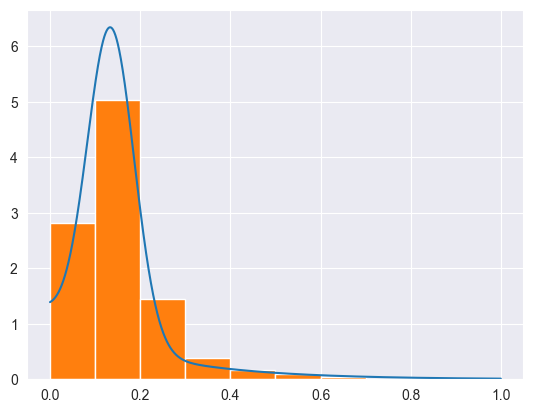

In [11]:
from matplotlib import pyplot as plt
x = np.arange(1, step=1/arr.size)
plt.plot(x, mix.pdf(x))
plt.hist(arr, density=True, bins=10)
plt.show()

In [12]:
print(mix.pdf(x))
data = mix.pdf(x)
norm = (data-np.min(data))/(np.max(data)-np.min(data))
print(trapezoid(mix.pdf(x),x))

[1.39069491 1.39176058 1.39285174 ... 0.01133101 0.01131847 0.01130595]
0.9939773367008944


In [13]:
indexHold = []
for z in range(2,data.size):
    if trapezoid(mix.pdf(x[:z]),x[:z]) > .95:
        indexHold.append(z)


In [17]:
print(np.percentile(data, 5))

0.014269925810705958
